In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

ZIP extract


In [7]:
import zipfile
import os

zip_path = "/content/archive (1).zip"
extract_path ="/content/online_food_data"


with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully!")


Extracted successfully!


Files ka naam check here


In [8]:
import os

for root, dirs, files in os.walk("/content/online_food_data"):
  for file in files:
    print(os.path.join(root, file))

/content/online_food_data/online food delivery dataset.csv


In [16]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        print(os.path.join(root, file))

/content/archive (1).zip
/content/.config/config_sentinel
/content/.config/.last_opt_in_prompt.yaml
/content/.config/gce
/content/.config/.last_update_check.json
/content/.config/.last_survey_prompt.yaml
/content/.config/hidden_gcloud_config_universe_descriptor_data_cache_configs.db
/content/.config/default_configs.db
/content/.config/active_config
/content/.config/configurations/config_default
/content/.config/logs/2026.09.04/13.24.51.717993.log
/content/.config/logs/2026.09.04/13.25.10.757956.log
/content/.config/logs/2026.09.04/13.24.04.448016.log
/content/.config/logs/2026.09.04/13.24.48.959800.log
/content/.config/logs/2026.09.04/13.25.09.479018.log
/content/.config/logs/2026.09.04/13.24.31.709670.log
/content/online_food_data/online food delivery dataset.csv
/content/sample_data/README.md
/content/sample_data/anscombe.json
/content/sample_data/mnist_train_small.csv
/content/sample_data/california_housing_train.csv
/content/sample_data/mnist_test.csv
/content/sample_data/californi

loading pandas dataset

In [17]:
import pandas as pd

df = pd.read_csv("/content/online_food_data/online food delivery dataset.csv")

df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes



 Checking dataset size

In [18]:
df.shape

(388, 14)

Column Names

In [19]:
df.columns


Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'Customer Type',
       'latitude', 'longitude', 'Pin code', 'Output', 'Feedback',
       'Unnamed: 13'],
      dtype='object')

Information about dataset

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    object 
 12  Feedback                    388 non-null    object 
 13  Unnamed: 13                 388 non

Checking missing value

In [21]:
df.isnull().sum()

,0
Age,0
Gender,0
Marital Status,0
Occupation,0
Monthly Income,0
Educational Qualifications,0
Family size,0
Customer Type,0
latitude,0
longitude,0


Feature (x) our Target  (y)  samajhna
SVM Need two Think
1. x = input/features - jin columns ke basis par prediction hogi

2. y = target - jo cheez predict krni hai

In [22]:
df.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'Customer Type',
       'latitude', 'longitude', 'Pin code', 'Output', 'Feedback',
       'Unnamed: 13'],
      dtype='object')

Checking output

In [24]:
df["Output"].value_counts()

,count
Output,
Yes,301
No,87


Unnamed: 13 removing

In [25]:
df = df.drop(columns=["Unnamed: 13"])
# Dataset se unnecessary column remove karna.
# After that we should have check once

In [26]:
df.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'Customer Type',
       'latitude', 'longitude', 'Pin code', 'Output', 'Feedback'],
      dtype='object')

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    object 
 12  Feedback                    388 non-null    object 
dtypes: float64(2), int64(3), object(8)


Categorical Data Encoding

In [32]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Marital Status",
        "Occupation",
        "Educational Qualifications",
        "Customer Type",
        "Feedback"

    ],
    drop_first=True
    # drop_first=True ek category ko remove karta hai, taaki redundant/dummy-variable information avoid ho.
)
df_encoded.head()





,Age,Monthly Income,Family size,latitude,longitude,Pin code,Output,Gender_Male,Marital Status_Prefer not to say,Marital Status_Single,Occupation_House wife,Occupation_Self Employeed,Occupation_Student,Educational Qualifications_Ph.D,Educational Qualifications_Post Graduate,Educational Qualifications_School,Educational Qualifications_Uneducated,Customer Type_New,Customer Type_Regular,Feedback_Positive
0,20,No Income,4,12.9766,77.5993,560001,Yes,False,False,True,False,False,True,False,True,False,False,False,False,True
1,24,Below Rs.10000,3,12.9770,77.5773,560009,Yes,False,False,True,False,False,True,False,False,False,False,False,True,True
2,22,Below Rs.10000,3,12.9551,77.6593,560017,Yes,True,False,True,False,False,True,False,True,False,False,False,True,False
3,22,No Income,6,12.9473,77.5616,560019,Yes,False,False,True,False,False,True,False,False,False,False,False,False,True
4,22,Below Rs.10000,4,12.9850,77.5533,560010,Yes,True,False,True,False,False,True,False,True,False,False,False,False,True


Check the numerical values

In [33]:
df_encoded.info

<bound method DataFrame.info of      Age  Monthly Income  Family size  latitude  longitude  Pin code Output  \
0     20       No Income            4   12.9766    77.5993    560001    Yes   
1     24  Below Rs.10000            3   12.9770    77.5773    560009    Yes   
2     22  Below Rs.10000            3   12.9551    77.6593    560017    Yes   
3     22       No Income            6   12.9473    77.5616    560019    Yes   
4     22  Below Rs.10000            4   12.9850    77.5533    560010    Yes   
..   ...             ...          ...       ...        ...       ...    ...   
383   23       No Income            2   12.9766    77.5993    560001    Yes   
384   23       No Income            4   12.9854    77.7081    560048    Yes   
385   22       No Income            5   12.9850    77.5533    560010    Yes   
386   23  Below Rs.10000            2   12.9770    77.5773    560009    Yes   
387   23       No Income            5   12.8988    77.5764    560078    Yes   

     Gender_Male  Marital Status_Prefer not to say  Marital Status_Single  \
0          False                             False                   True   
1          False                             False                   True   
2           True                             False                   True   
3          False                             False                   True   
4           True                             False                   True   
..           ...                               ...                    ...   
383        False                             False                   True   
384        False                             False                   True   
385        False                             False                   True   
386         True                             False                   True   
387         True                             False                   True   

     Occupation_House wife  Occupation_Self Employeed  Occupation_Student  \
0                    False                      False                True   
1                    False                      False                True   
2                    False                      False                True   
3                    False                      False                True   
4                    False                      False                True   
..                     ...                        ...                 ...   
383                  False                      False                True   
384                  False                      False                True   
385                  False                      False                True   
386                  False                      False                True   
387                  False                      False                True   

     Educational Qualifications_Ph.D  \
0                              False   
1                              False   
2                              False   
3                              False   
4                              False   
..                               ...   
383                            False   
384                            False   
385                            False   
386                            False   
387                            False   

     Educational Qualifications_Post Graduate  \
0                                        True   
1                                       False   
2                                        True   
3                                       False   
4                                        True   
..                                        ...   
383                                      True   
384                                      True   
385                                      True   
386                                      True   
387                                      True   

     Educational Qualifications_School  Educational Qualifications_Uneducated  \
0                 

Create  X aur Y

In [37]:
X = df_encoded.drop(columns=["Output"])
y = df_encoded["Output"]

In [38]:
print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (388, 19)
y shape: (388,)


In [39]:
print(X.head())
print(y.head())

   Age  Monthly Income  Family size  latitude  longitude  Pin code  \
0   20       No Income            4   12.9766    77.5993    560001   
1   24  Below Rs.10000            3   12.9770    77.5773    560009   
2   22  Below Rs.10000            3   12.9551    77.6593    560017   
3   22       No Income            6   12.9473    77.5616    560019   
4   22  Below Rs.10000            4   12.9850    77.5533    560010   

   Gender_Male  Marital Status_Prefer not to say  Marital Status_Single  \
0        False                             False                   True   
1        False                             False                   True   
2         True                             False                   True   
3        False                             False                   True   
4         True                             False                   True   

   Occupation_House wife  Occupation_Self Employeed  Occupation_Student  \
0                  False                      False  

Check the size

In [43]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (310, 19)
X_test: (78, 19)
y_train: (310,)
y_test: (78,)


Feature Scaling


In [46]:
df["Monthly Income"].value_counts()

,count
Monthly Income,
No Income,187
25001 to 50000,69
More than 50000,62
10001 to 25000,45
Below Rs.10000,25


In [49]:
df["Monthly Income"] = df["Monthly Income"].replace("No Income", 0)

In [50]:
print(df["Monthly Income"].unique())

[0 'Below Rs.10000' 'More than 50000' '10001 to 25000' '25001 to 50000']


Coverting income in numerical values

In [61]:
income_mapping = {
    "No Income": 0,
    "Below Rs.10000": 5000,
    "10001 to 25000": 17500,
    "25001 to 50000": 37500,
    "More than 50000": 60000
}

df["Monthly Income"] = df["Monthly Income"].map(income_mapping)

print(df["Monthly Income"].unique())
print(df["Monthly Income"].isnull().sum())

[    0  5000 60000 17500 37500]
0


In [63]:
X = df_encoded.drop(columns=["Output"])
y = df_encoded["Output"]

print(X.dtypes)

Age                                           int64
Monthly Income                               object
Family size                                   int64
latitude                                    float64
longitude                                   float64
Pin code                                      int64
Gender_Male                                    bool
Marital Status_Prefer not to say               bool
Marital Status_Single                          bool
Occupation_House wife                          bool
Occupation_Self Employeed                      bool
Occupation_Student                             bool
Educational Qualifications_Ph.D                bool
Educational Qualifications_Post Graduate       bool
Educational Qualifications_School              bool
Educational Qualifications_Uneducated          bool
Customer Type_New                              bool
Customer Type_Regular                          bool
Feedback_Positive                              bool
dtype: objec

In [67]:
print(X.select_dtypes(include=["object"]).columns)

Index(['Unnamed: 13'], dtype='object')


In [68]:
for col in X.select_dtypes(include=["object"]).columns:
    print("\n", col)
    print(X[col].unique())


 Unnamed: 13
['Yes' 'No']


In [69]:
df = df.drop(columns=["Unnamed: 13"])

print(df.columns)

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'Customer Type',
       'latitude', 'longitude', 'Pin code', 'Output', 'Feedback'],
      dtype='object')


In [70]:
df_encoded = pd.get_dummies(
    df,
    columns=[
        "Gender",
        "Marital Status",
        "Occupation",
        "Educational Qualifications",
        "Customer Type",
        "Feedback"
    ],
    drop_first=True
)

X = df_encoded.drop(columns=["Output"])
y = df_encoded["Output"]

print("Text columns in X:")
print(X.select_dtypes(include=["object"]).columns)

Text columns in X:
Index([], dtype='object')


split

In [71]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Scaling

In [72]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully")

Scaling completed successfully


SVM Classifier

In [73]:
from sklearn.svm import SVC

model = SVC(
    kernel="rbf",
    random_state=42
)

model.fit(X_train_scaled, y_train)

print("SVM model trained successfully")

SVM model trained successfully


**Short Explanation:**

* **Why write this code?** To train an AI model to learn patterns from past data so it can automatically predict future outcomes.
* **`SVC`:** Sets up the classification algorithm (Support Vector Machine) to separate data into groups.
* **`kernel="rbf"`:** Helps the model understand complex, non-linear relationships that can't be split with a simple straight line.
* **`model.fit()`:** Feeds the data to the model so it actually learns the patterns and gets ready to make predictions.

Prediction

In [74]:
y_pred = model.predict(X_test_scaled)

print(y_pred)

['No' 'Yes' 'Yes' 'Yes' 'No' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'No'
 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'Yes'
 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes'
 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'Yes' 'No' 'Yes' 'Yes' 'No' 'Yes' 'Yes'
 'Yes' 'No' 'Yes' 'Yes' 'Yes']


Accuracy

In [75]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.8717948717948718
Accuracy (%): 87.17948717948718


Confusion Matrix

In [76]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 6  6]
 [ 4 62]]


 select two features

In [80]:
# Sirf visualization ke liye 2 features select kar rahe hain
X_2d = df[["Age", "Family size"]].copy()

# Target Yes/No ko 0/1 me convert kar rahe hain
y_2d = df["Output"].map({
    "No": 0,
    "Yes": 1
})

print(X_2d.head())
print(y_2d.head())

   Age  Family size
0   20            4
1   24            3
2   22            3
3   22            6
4   22            4
0    1
1    1
2    1
3    1
4    1
Name: Output, dtype: int64


2D data ko scale

In [81]:
from sklearn.preprocessing import StandardScaler

scaler_2d = StandardScaler()

X_2d_scaled = scaler_2d.fit_transform(X_2d)

print("2D scaling completed")

2D scaling completed


2D SVM train

In [82]:
from sklearn.svm import SVC

svm_2d = SVC(
    kernel="linear",
    random_state=42
)

svm_2d.fit(X_2d_scaled, y_2d)

print("2D SVM trained successfully")

2D SVM trained successfully


Decision Boundary Graph

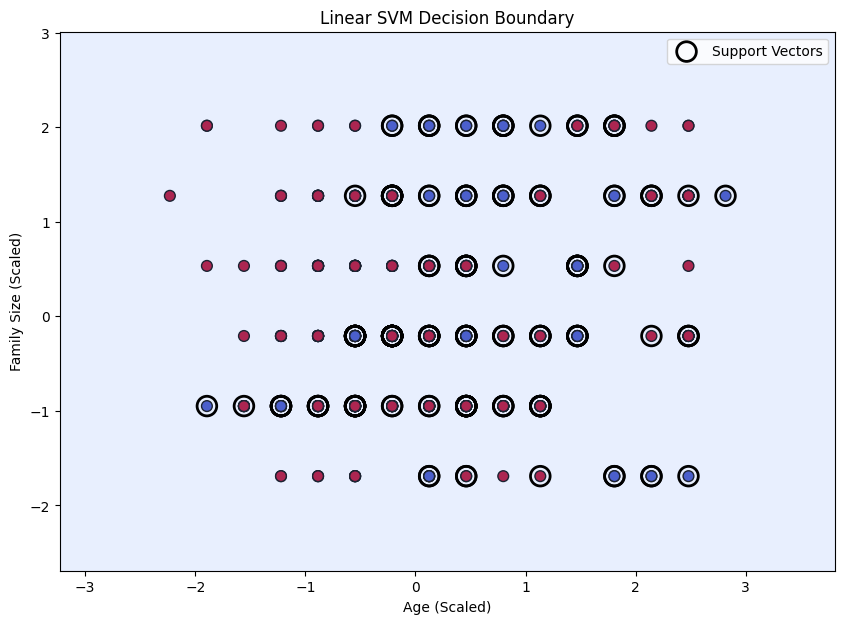

In [83]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Actual data points
plt.scatter(
    X_2d_scaled[:, 0],
    X_2d_scaled[:, 1],
    c=y_2d,
    cmap="coolwarm",
    edgecolors="k",
    s=60
)

# Mesh grid create karna
x_min = X_2d_scaled[:, 0].min() - 1
x_max = X_2d_scaled[:, 0].max() + 1

y_min = X_2d_scaled[:, 1].min() - 1
y_max = X_2d_scaled[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

# Grid points par prediction
Z = svm_2d.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

# Decision regions
plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.2,
    cmap="coolwarm"
)

# Decision boundary
plt.contour(
    xx,
    yy,
    Z,
    colors="black",
    linewidths=1
)

# Support Vectors
plt.scatter(
    svm_2d.support_vectors_[:, 0],
    svm_2d.support_vectors_[:, 1],
    s=200,
    facecolors="none",
    edgecolors="black",
    linewidths=2,
    label="Support Vectors"
)

plt.xlabel("Age (Scaled)")
plt.ylabel("Family Size (Scaled)")
plt.title("Linear SVM Decision Boundary")

plt.legend()
plt.show()

Classification Report

In [77]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.60      0.50      0.55        12
         Yes       0.91      0.94      0.93        66

    accuracy                           0.87        78
   macro avg       0.76      0.72      0.74        78
weighted avg       0.86      0.87      0.87        78



Accuracy only shows overall performance. The classification report breaks it down for each class (Yes and No):

Precision → How often the model was correct when it predicted Yes/No.

Recall → How many of the actual Yes/No cases the model correctly identified.

F1-score → The combined balance of Precision and Recall.